<a href="https://colab.research.google.com/github/maehwa0967/2026BDA/blob/main/VDS%EA%B5%90%ED%86%B5%EB%9F%89%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
# Colab 환경 한글 폰트 적용
!pip install koreanize-matplotlib
import koreanize_matplotlib
%config InlineBackend.figure_format = 'retina'

In [ ]:
# 2. 원천 데이터 로드 및 전처리 (VDS.csv)
try:
    df = pd.read_csv('VDS.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('VDS.csv', encoding='cp949')

# 결측치(-1) 데이터 제거 및 타입 변환
df_clean = df[(df['평균속도'] > 0) & (df['교통량'] > 0)].copy()
df_clean['기준시간'] = df_clean['기준시간'].astype(int)
df_clean['평균속도'] = df_clean['평균속도'].astype(float)
df_clean['교통량'] = df_clean['교통량'].astype(float)

데이터를 불러오는 중입니다...


In [ ]:
# 3. [데이터 확인] 원본 데이터프레임(DataFrame) 기초 구조 및 샘플 표출
# 포인트: "본격적인 시각화에 앞서, 우리가 분석할 실제 원천 데이터의 형태와 규모를 확인합니다."
from IPython.display import display

print("📊 [기초 데이터프레임 요약 정보]")
print(f"- 분석 대상 데이터 건수 (통신오류/결측치 제외): {len(df_clean):,}건")
print(f"- 수집된 고속도로 노선 수: {df_clean['도로명'].nunique()}개")
print(f"- 주요 수집 항목(컬럼): {', '.join(df_clean.columns)}")

display(df_clean.head())

# 속도와 교통량의 평균, 최소/최대값, 4분위수를 출력하여 데이터의 분포 확인
display(df_clean[['기준시간', '교통량', '평균속도']].describe().round(2))

📊 [기초 데이터프레임 요약 정보]
- 분석 대상 데이터 건수 (통신오류/결측치 제외): 564,568건
- 수집된 고속도로 노선 수: 68개
- 주요 수집 항목(컬럼): 기준시간, 기준시, 기준일, VDS_ID, 요일명, 지점이정, 노드명, 도로이정, 노선번호, 도로명, 교통량, 평균속도, Unnamed: 12

🔍 [데이터프레임 상위 5개 샘플 (Head)]


,기준시간,기준시,기준일,VDS_ID,요일명,지점이정,노드명,도로이정,노선번호,도로명,교통량,평균속도,Unnamed: 12
0,0,0,20260523,0010VDE00100,토요일,1.4,구서IC,0.20,10,경부선,108.0,86.12,NaN
1,0,0,20260523,0010VDE00200,토요일,2.4,영락IC,2.02,10,경부선,109.0,97.17,NaN
3,0,0,20260523,0010VDE00401,토요일,4.5,부산TG,4.01,10,경부선,76.0,101.25,NaN
7,0,0,20260523,0010VDE00801,토요일,8.4,노포JC,5.58,10,경부선,61.0,103.80,NaN
8,0,0,20260523,0010VDE00900,토요일,9.2,노포JC,5.58,10,경부선,59.0,101.37,NaN



📈 [주요 수치형 변수 기초 통계량 (Describe)]


,기준시간,교통량,평균속도
count,564568.00,564568.00,564568.00
mean,11.50,280.57,98.42
std,6.93,254.82,17.24
min,0.00,1.00,1.00
25%,5.00,79.00,93.00
50%,11.00,208.00,98.98
75%,18.00,420.00,105.09
max,23.00,2038.00,263.77


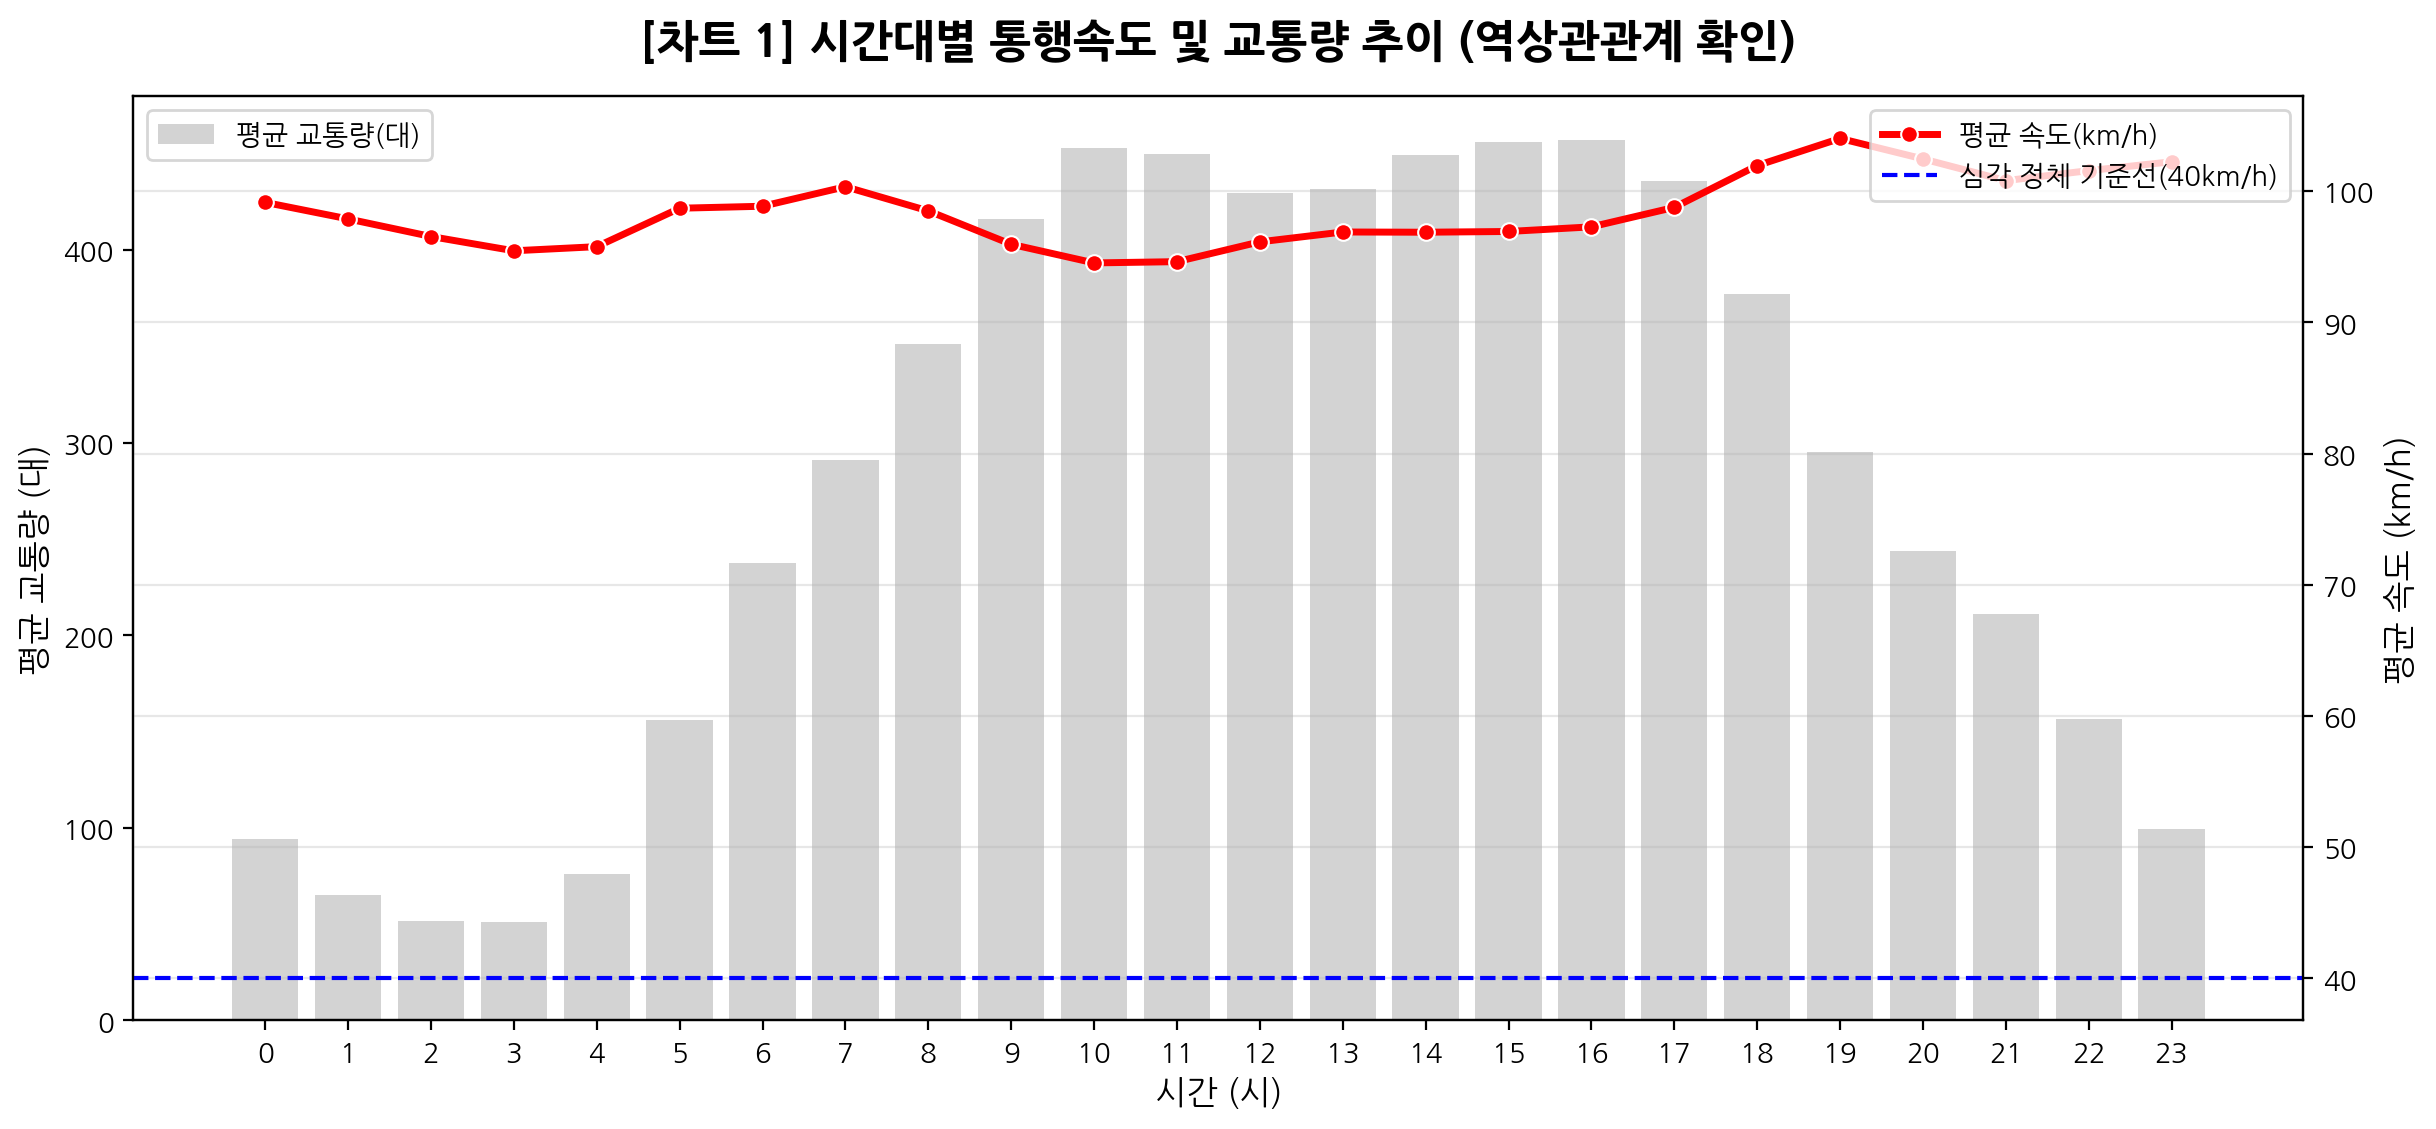

In [ ]:

# 4. [시각화 1] 시간대별 고속도로 전체 교통량 및 평균속도 추이
# 포인트: "언제 차가 가장 많이 몰리고, 속도가 떨어지는가?"
plt.figure(figsize=(14, 6))

time_grouped = df_clean.groupby('기준시간')[['교통량', '평균속도']].mean().reset_index()

ax1 = sns.barplot(x='기준시간', y='교통량', data=time_grouped, color='lightgray', label='평균 교통량(대)')
ax2 = ax1.twinx()
sns.lineplot(x='기준시간', y='평균속도', data=time_grouped, color='red', marker='o', linewidth=2.5, label='평균 속도(km/h)', ax=ax2)

ax1.set_title('[차트 1] 시간대별 통행속도 및 교통량 추이 (역상관관계 확인)', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('시간 (시)', fontsize=12)
ax1.set_ylabel('평균 교통량 (대)', fontsize=12)
ax2.set_ylabel('평균 속도 (km/h)', fontsize=12)
ax2.axhline(40, color='blue', linestyle='--', linewidth=1.5, label='심각 정체 기준선(40km/h)')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()

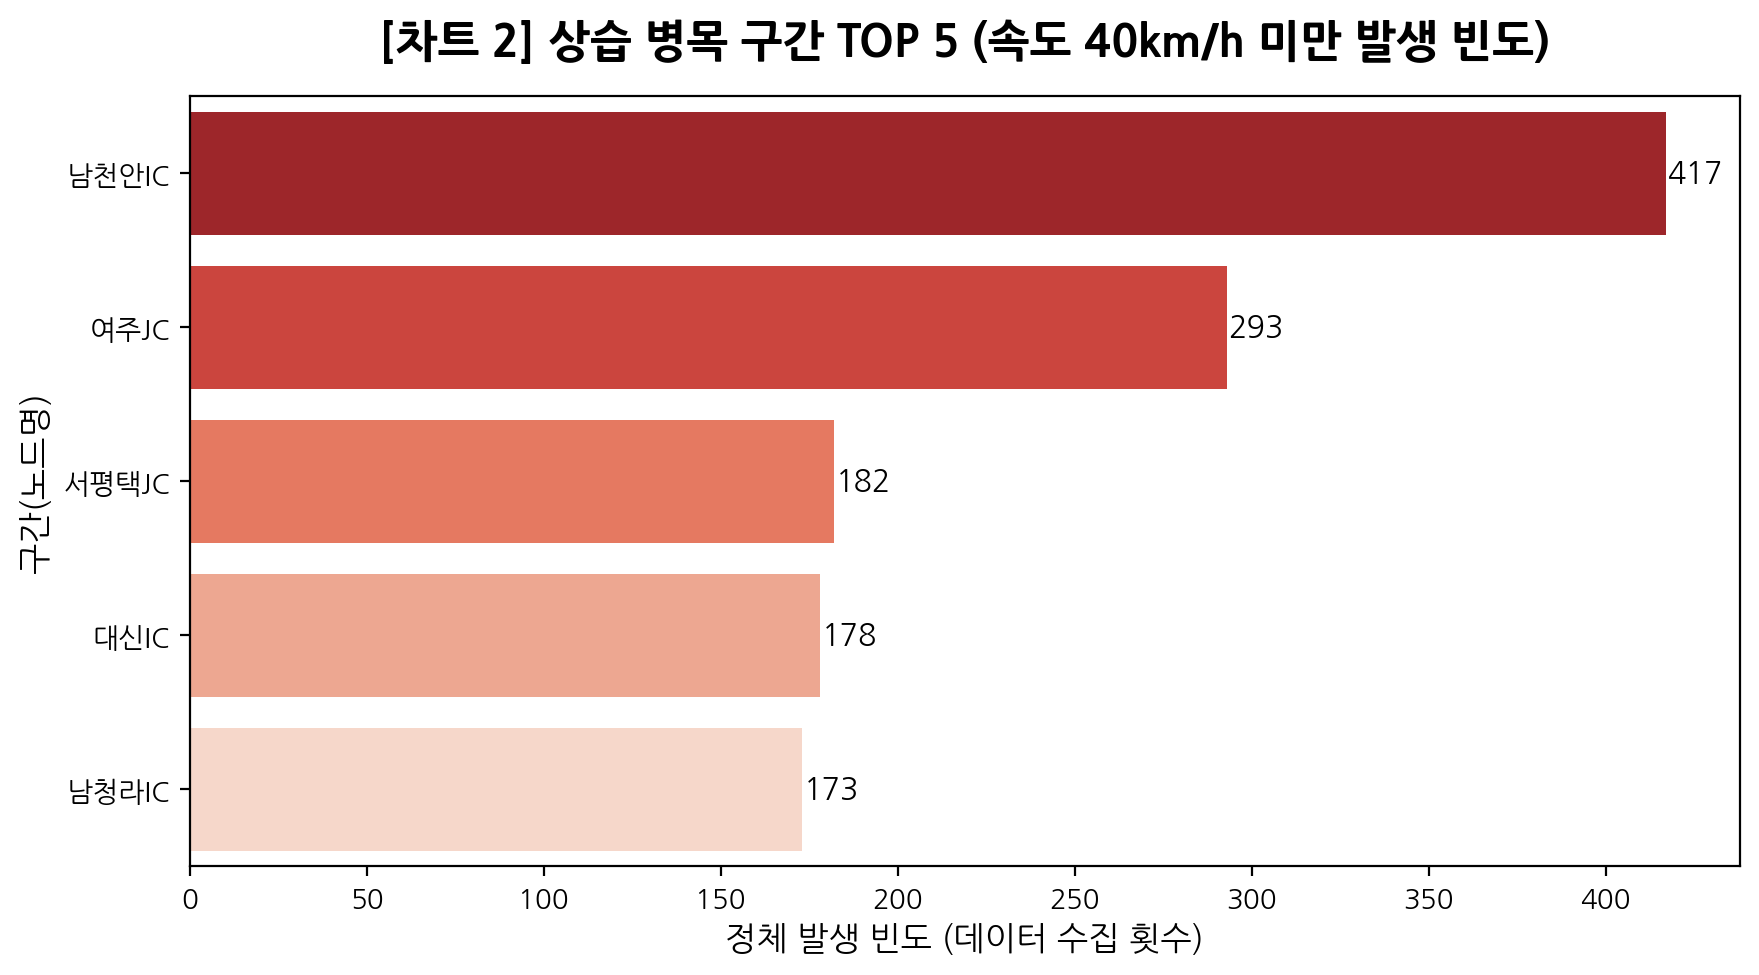

In [ ]:
# 4. [시각화 2] 극심한 병목 현상(40km/h 미만) 상위 5개 구간 파악,
congestion_df = df_clean[df_clean['평균속도'] < 40]

if not congestion_df.empty:
    top_bottlenecks = congestion_df.groupby('노드명')['평균속도'].count().nlargest(5).reset_index()
    top_bottlenecks.columns = ['노드명', '정체발생횟수']

    plt.figure(figsize=(10, 5))
    sns.barplot(x='정체발생횟수', y='노드명', data=top_bottlenecks, palette='Reds_r')
    plt.title('[차트 2]  상습 병목 구간TOP 5 (속도 40km/h 미만 발생 빈도)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('정체 발생 빈도 (데이터 수집 횟수)', fontsize=12)
    plt.ylabel('구간(노드명)', fontsize=12)

    # 막대 끝에 수치 표시
    for index, value in enumerate(top_bottlenecks['정체발생횟수']):
        plt.text(value + 0.5, index, str(value), va='center', fontsize=11)

    plt.show()
else:
    print("40km/h 미만의 정체 구간이 없습니다.")

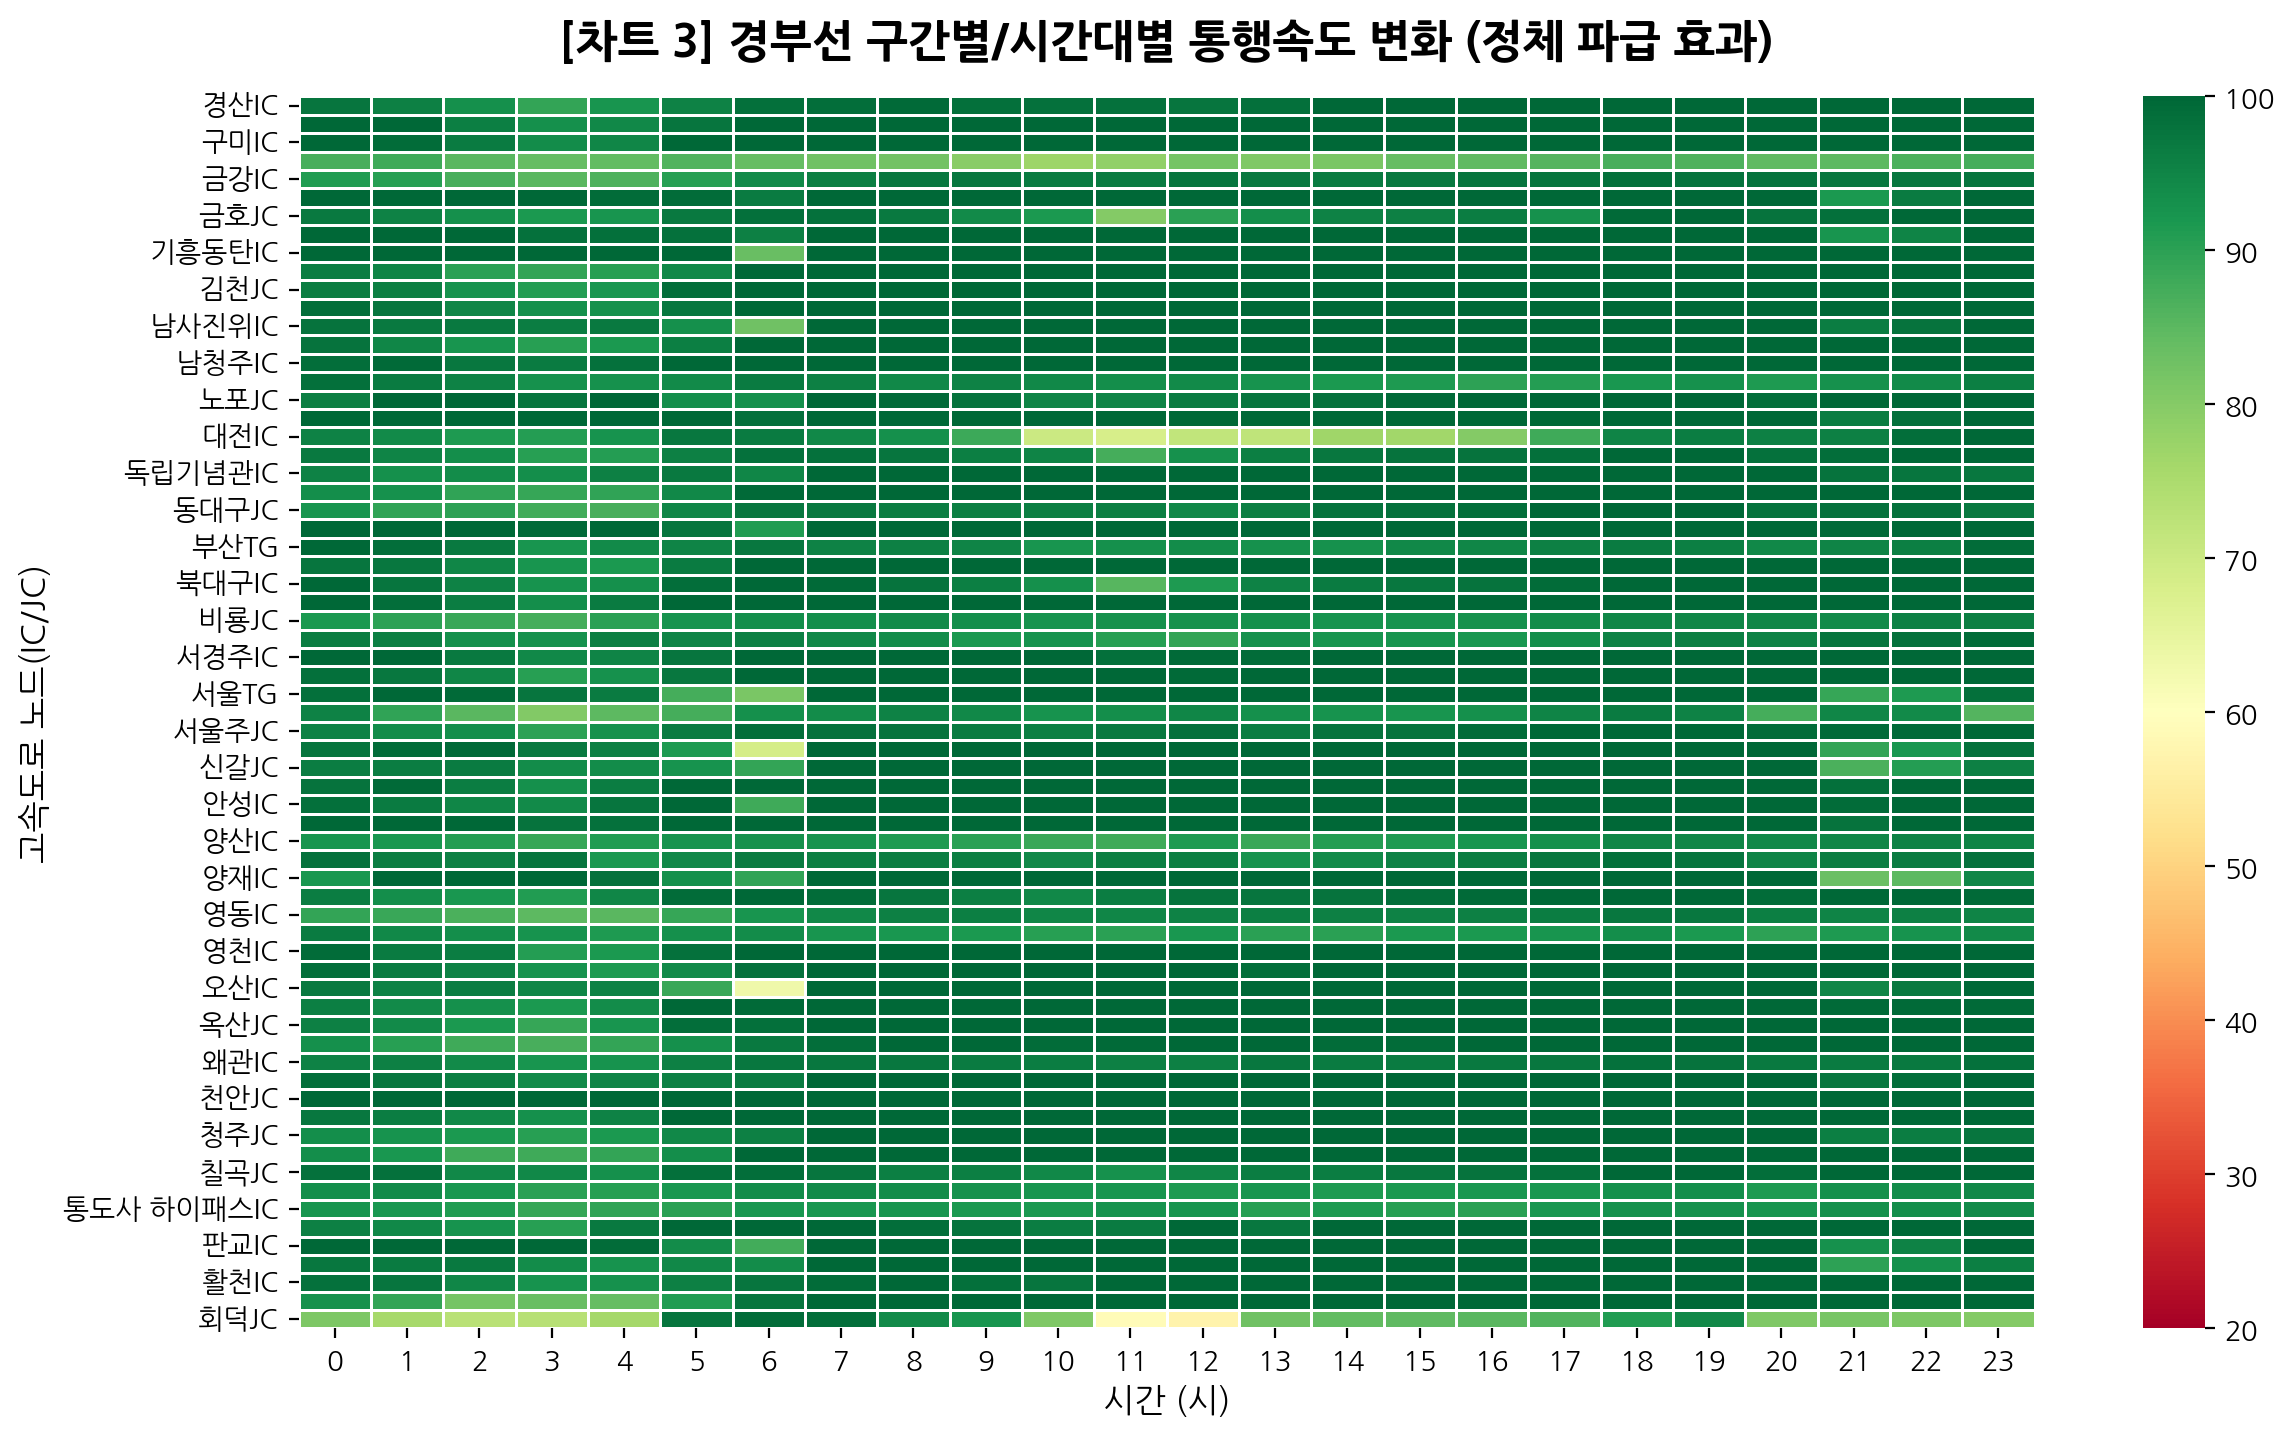

In [ ]:
# 5. [시각화 3] 핵심 노선의 시공간(Time-Space) 통행속도 히트맵
# "특정 지점에서 시작된 정체가 시간의 흐름에 따라 어떻게 앞뒤 구간으로 퍼져나가는가?"
main_route = df_clean['도로명'].value_counts().index[0] # 데이터가 가장 많은 주요 노선 자동 선택
route_df = df_clean[df_clean['도로명'] == main_route]
heatmap_data = route_df.pivot_table(index='노드명', columns='기준시간', values='평균속도', aggfunc='mean')

plt.figure(figsize=(14, 8))
# 붉은색(정체 20km/h) -> 녹색(원활 100km/h)
sns.heatmap(heatmap_data, cmap='RdYlGn', vmin=20, vmax=100, annot=False, linewidths=.5)
plt.title(f'[차트 3] {main_route} 구간별/시간대별 통행속도 변화 (정체 파급 효과)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('시간 (시)', fontsize=12)
plt.ylabel('고속도로 노드(IC/JC)', fontsize=12)
plt.yticks(rotation=0)
plt.show()

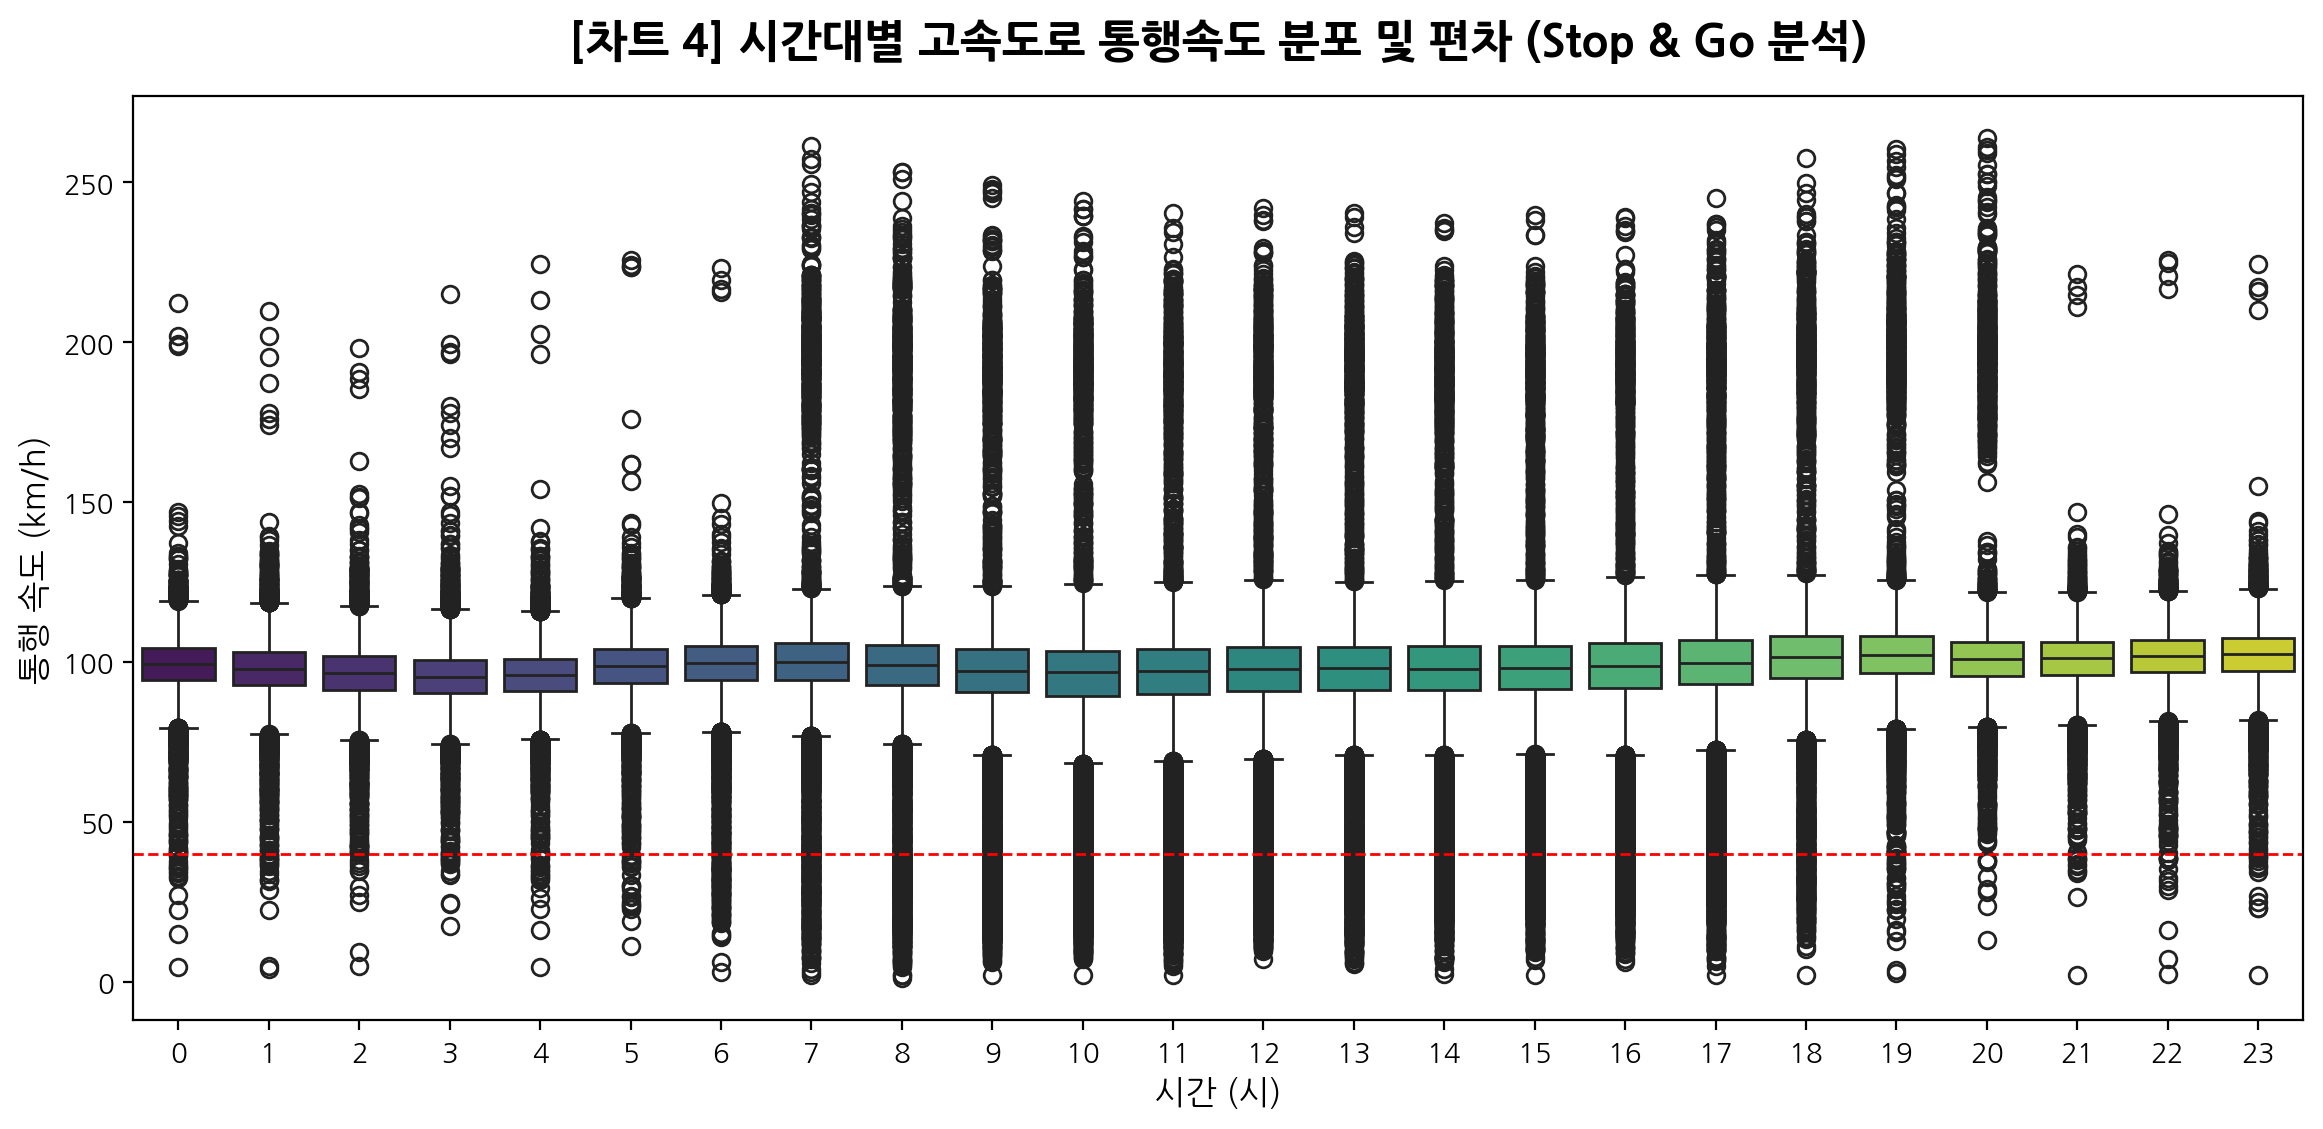

In [ ]:
# 6. [시각화 4] 시간대별 통행속도 편차 (가다-서다 반복 구간 확인)
# 발표 포인트: "막히는 시간대에는 속도 저하뿐만 아니라 차량 간 속도 편차가 커져 사고 위험이 높다"
plt.figure(figsize=(14, 6))
sns.boxplot(x='기준시간', y='평균속도', data=df_clean, palette='viridis')
plt.title('[차트 4] 시간대별 고속도로 통행속도 분포 및 편차 (Stop & Go 분석)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('시간 (시)', fontsize=12)
plt.ylabel('통행 속도 (km/h)', fontsize=12)
plt.axhline(40, color='red', linestyle='--', linewidth=1) # 40km/h 기준선
plt.show()

## 결론
1. [현상 파악] [차트 1]을 통해 교통량이 특정 시간대에 급증할 때 평균 속도가 하락하는 명확한 역상관관계를 확인했습니다.
2. [병목 특정] [차트 2]의 데이터를 바탕으로, 막연한 정체가 아닌 극심한 체증을 유발하는 상위 5개 노드(최초 병목 지점)를 구체적으로 식별했습니다.
3. [파급 분석] [차트 3]의 히트맵(붉은색 영역)은 특정 노드에서 발생한 정체가 인접 구간으로 확산(Shockwave)되는 구조적 한계를 실증합니다.
4. [안전 문제] [차트 4]에서 보듯 정체 시간대에는 통행 속도의 박스플롯(Box) 꼬리가 길어지며 '가다-서다(Stop & Go)'가 반복되어 추돌 사고 위험이 높습니다.

 ## 해결 방안 제안
- (진입 통제) 차트 2에서 식별된 최상위 병목 노드 진입로에 '램프 미터링(신호등)'을 도입하여 본선 교통량 포화를 방지해야 합니다.
- (속도 제어) 차트 4의 속도 편차를 줄이기 위해, 정체 구간 후방 5km 지점부터 '가변 제한 속도(VSL)'를 적용하여 차량 흐름을 안정화해야 합니다.